# Neural Network–Based Credit Risk Prediction Using MLP
### **Student Detailed**:
- **Name** : Jitin Kumar Sengar
- **Roll Number** : 2501940073
- **Course**: Deep Learning Architectures and Techniques
- **Course Code**: ETMMDL274

## Step 1: Import Required Libraries

**What are we doing here?**

Think of this step like gathering all the tools we need before starting a construction project. In our case, we're building a neural network to predict loan defaults, so we need to import several Python libraries that will help us throughout the process.

**Why do we need these libraries?**

- **Pandas and NumPy**: These help us work with data in tables and perform mathematical calculations
- **Matplotlib and Seaborn**: These create beautiful charts and graphs to visualize our data
- **Scikit-learn**: This provides tools to split data, scale features, and evaluate our model's performance
- **TensorFlow/Keras**: This is our main tool for building the neural network (the "brain" of our system)

Just like a chef gathers all ingredients before cooking, we import all necessary libraries at the beginning of our project!

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and model evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Reproducibility
import tensorflow as tf
import random

## Step 2: Load the Loan Default Dataset

**What are we doing here?**

We're loading our dataset into the program so we can work with it. Think of this like opening an Excel file on your computer - we need to first open the file before we can look at or change the data inside.

**Why is this important?**

Before we can build any prediction model, we need to understand what data we have. The dataset contains information about people who took loans - things like their income, credit score, loan amount, and whether they defaulted (failed to repay) or not.

**What should we check for?**

When working with real-world data, we often find:
- **Missing information**: Some people might not have provided all details
- **Text data**: Things like gender, region, etc. need special handling
- **Unbalanced data**: Maybe we have way more non-defaulters than defaulters
- **Unnecessary columns**: Some information might be useless for prediction

Let's start by simply loading the data and taking a quick peek at what it looks like!

In [15]:
# Load dataset
df = pd.read_csv("/content/sample_data/Loan_Default.csv")

# Display first 5 rows
df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


### Understanding What We Just Did

**`pd.read_csv()`** - The File Reader

This command reads our CSV (Comma Separated Values) file and converts it into something called a DataFrame. Think of a DataFrame as a smart Excel spreadsheet that Python can understand and manipulate.

**`df.head()`** - Taking a Quick Peek

This shows us the first 5 rows of our dataset. It's like flipping to the first page of a book to get a sense of what it's about.

**What are we looking for?**

When we look at these first few rows, we want to notice:
- **Column names**: What information do we have? (e.g., age, income, credit score)
- **Data types**: Are values numbers or text?
- **The target**: Which column tells us if someone defaulted? (This is what we want to predict)
- **Categories**: Which columns have text like "Male/Female" or "North/South"?
- **Quality issues**: Do we see any weird values or blanks?

This quick look helps us plan our next steps!

## Step 3: Understanding the Dataset Structure

**What are we doing here?**

Before we start building our model, we need to properly understand our dataset - just like a doctor examines a patient before prescribing treatment. We need to know exactly what we're working with.

**Why is this step so important?**

Neural networks are very particular about their input. They need:
- ✓ Clean data (no missing pieces)
- ✓ Numbers only (no text)
- ✓ Proper formatting

If we skip this step and feed messy data into our model, it will either fail completely, or worse - give us wrong predictions!

**What will we check?**

We'll use three simple commands to get a complete picture:

1. **`df.shape`** - Shows us the size of our dataset
   - How many rows? (Each row = one loan application)
   - How many columns? (Each column = one piece of information)

2. **`df.info()`** - Shows us the details of each column
   - What type of data? (numbers vs text)
   - Are there any missing values?

3. **`df.isnull().sum()`** - Counts exactly how many values are missing in each column
   - This tells us which columns need cleaning

Let's run these commands and see what we discover!

In [16]:
# Dataset shape
print("Dataset shape:", df.shape)

# Column information
df.info()

# Check missing values
df.isnull().sum()

Dataset shape: (148670, 34)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  U

,0
ID,0
year,0
loan_limit,3344
Gender,0
approv_in_adv,908
loan_type,0
loan_purpose,134
Credit_Worthiness,0
open_credit,0
business_or_commercial,0


## Step 4: Removing Irrelevant Columns and Defining Target Variable

**What are we doing here?**

We're doing two important things: removing useless information and clearly identifying what we're trying to predict.

**Part 1: Removing the ID Column**

The **ID column** is just a unique number assigned to each loan application (like 1, 2, 3, 4...). It's similar to a serial number - it helps identify records but tells us nothing about whether someone will default or not.

Think about it: Does the fact that someone is applicant number 1234 vs 5678 tell us anything about their ability to repay a loan? No! So we remove it to avoid confusing our model.

**Part 2: Defining Our Target Variable**

In machine learning, we need to be crystal clear about what we're trying to predict. This is called the **target variable** or **label**.

In our case, the **Status** column is our target:
- **Status = 1** means the person **defaulted** (failed to repay the loan) ❌
- **Status = 0** means the person **did NOT default** (successfully repaid) ✅

**Part 3: Defining Input Features**

Everything else in the dataset (except Status) becomes our **input features**. These are the pieces of information our model will use to make predictions - things like income, credit score, loan amount, interest rate, etc.

So we're basically saying: "Use all these features to predict the Status!"

In [17]:
# Remove ID column
df = df.drop(columns=['ID'])

# Define target variable
y = df['Status']

# Define input features
X = df.drop(columns=['Status'])

# Display shapes
print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (148670, 32)
Target vector shape: (148670,)


## Step 5: Handling Missing Values

**What is the problem?**

Real-world data is messy! In financial datasets, we often find blank spaces (missing values) because:
- Someone forgot to fill in a form field
- The information wasn't collected
- Data got lost during transfer
- Some values were not applicable

**Why can't we just ignore missing values?**

Neural networks are like very strict teachers - they cannot work with incomplete information. If we try to feed them data with blanks, they'll simply refuse to work (throw an error). So we MUST fix all missing values before training.

**How do we fix this problem?**

We use different strategies for different types of data:

**For Number Columns** (like income, age, credit score):
- We fill blanks with the **median** (middle value) of that column
- **Why median?** Because it's not affected by extreme values. For example, if most incomes are around $50,000 but one person makes $10 million, the median stays reasonable while the average would be inflated.

**For Text Columns** (like gender, region, loan type):
- We fill blanks with the **mode** (most common value)
- **Why mode?** If 80% of applicants are from the "North" region, it makes sense to assume a missing region is probably also "North"

This way, we keep our data realistic without losing any rows of valuable information!

In [18]:
# Separate numerical and categorical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# Fill missing values for numerical columns using median
for col in num_cols:
    X[col] = X[col].fillna(X[col].median())

# Fill missing values for categorical columns using mode
for col in cat_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

# Verify missing values are handled
X.isnull().sum().sum()

np.int64(0)

## Step 6: Encoding Categorical Variables

**What is the problem?**

Neural networks are mathematical models - they only understand numbers! But our dataset contains text values like:
- Gender: "Male", "Female"
- Region: "North", "South", "East", "West"
- Loan Type: "Education", "Home", "Personal"

We need to convert these text categories into numbers that our model can process.

**What is One-Hot Encoding?**

One-Hot Encoding is a clever technique that converts each category into a separate binary (0 or 1) column. It's like turning on a light switch for the category that applies.

**Let me explain with an example:**

Imagine we have a "Region" column with three values:

**Original data:**
- Person 1: North
- Person 2: South  
- Person 3: East

**After One-Hot Encoding:**
```
Person 1: [Region_North=1, Region_South=0, Region_East=0]
Person 2: [Region_North=0, Region_South=1, Region_East=0]
Person 3: [Region_North=0, Region_South=0, Region_East=1]
```

Only ONE column is "hot" (=1) at a time, others are 0.

**Why not just use 1, 2, 3 for North, South, East?**

Because the model might think North(1) + South(2) = East(3), or that East is "bigger" than North. But regions don't have any mathematical relationship! One-Hot Encoding prevents this confusion by treating each category independently.

In [19]:
# Apply one-hot encoding to categorical features
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Check new dataset shape
print("Shape after encoding:", X.shape)

Shape after encoding: (148670, 49)


## Step 7: Feature Scaling

**What is the problem?**

Different features in our dataset have very different scales. For example:
- **Credit Score**: ranges from 300 to 850
- **Loan Amount**: could be 5,000 to 500,000
- **LTV Ratio**: ranges from 0 to 100 (percentage)
- **Age**: ranges from 18 to 70

**Why is this a problem for neural networks?**

Neural networks learn by adjusting weights. If one feature has huge numbers (like loan amount: 500,000) and another has small numbers (like age: 25), the model will pay way more attention to the big numbers. It's like trying to have a conversation with someone whispering and someone shouting - you'll mostly hear the loud person!

**What is the solution?**

We use **Standardization** (also called Z-score normalization). This transforms ALL features to have:
- **Mean = 0** (centered around zero)
- **Standard Deviation = 1** (similar spread)

**The magic formula:**

```
Standardized Value = (Original Value - Mean) / Standard Deviation
```

**What does this achieve?**

After standardization, all features are on the same playing field:
- A credit score of 700 might become 0.5
- A loan amount of 100,000 might become 0.3
- An age of 30 might become -0.2

Now the neural network can learn from ALL features fairly, not just the ones with big numbers. This makes training faster and more accurate!

In [20]:
# Initialize scaler
scaler = StandardScaler()

# Apply scaling
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame (optional but helpful for inspection)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Scaled dataset shape:", X_scaled.shape)

Scaled dataset shape: (148670, 49)


## Step 8: Train–Test Split

**What are we doing here?**

We're dividing our dataset into two separate groups. Think of it like this: if you're studying for an exam, you practice with some questions (training) and test yourself with different questions (testing) to see if you really learned.

**The Two Groups:**

**1. Training Set (80% of data)**
- This is what our neural network will learn from
- It's like the practice problems a student uses to learn
- The model sees these examples and learns the patterns

**2. Testing Set (20% of data)**
- This is kept completely separate and hidden during training
- It's like the actual exam questions
- After training, we use this to see if our model can handle NEW data it has never seen before

**Why not use all data for training?**

If we use all data for training, we won't know if our model actually learned general patterns or just memorized the specific examples. It's like a student who memorizes answers without understanding - they fail when questions change slightly!

By keeping 20% of data hidden, we can test if our model truly understands loan default patterns.

**What is random_state=42?**

This is like setting a random seed. It ensures that every time we run this code, we get the exact same split. This makes our results reproducible - if someone else runs our code, they'll get the same results. (42 is just a number - we could use any number, but 42 is popular because of "The Hitchhiker's Guide to the Galaxy"!)

In [21]:
from sklearn.model_selection import train_test_split

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (118936, 49)
Testing samples: (29734, 49)


## Step 9: Building the Multi-Layer Perceptron (MLP)

**What is a Multi-Layer Perceptron?**

A Multi-Layer Perceptron (MLP) is like an artificial brain made up of layers of connected neurons. Just like your brain has neurons that fire when they receive signals, an MLP has artificial neurons that activate when they receive input.

**Understanding Our Network Architecture:**

Let's break down our neural network layer by layer:

**🔹 Input Layer**
- This is where our 49 features enter the network
- Think of it as the "eyes" that receive information about a loan application
- No computations happen here - it's just the entry point

**🔹 First Hidden Layer (64 neurons)**
- Contains 64 artificial neurons that process the input
- Each neuron looks at ALL 49 input features and learns to detect specific patterns
- Uses **ReLU activation**: This is like a filter that only passes positive signals forward. It helps the network learn complex patterns while keeping computations simple and fast.

**🔹 Second Hidden Layer (32 neurons)**
- Contains 32 neurons that process information from the first layer
- This layer learns even more complex combinations of patterns
- Also uses **ReLU activation**
- Having two hidden layers allows the network to learn deeper, more abstract patterns

**🔹 Output Layer (1 neuron)**
- This single neuron gives us the final prediction
- Uses **Sigmoid activation**: This squashes the output between 0 and 1, which we interpret as a probability
- Output close to 0 = Low chance of default
- Output close to 1 = High chance of default

This architecture is like a funnel: 49 inputs → 64 neurons → 32 neurons → 1 output

In [22]:
# Build the MLP model
model = Sequential()

# Input + First hidden layer
model.add(Dense(64, activation='relu', input_shape=(49,)))

# Second hidden layer
model.add(Dense(32, activation='relu'))

# Output layer
model.add(Dense(1, activation='sigmoid'))

# Display model architecture
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,313 (20.75 KB)

 Trainable params: 5,313 (20.75 KB)

 Non-trainable params: 0 (0.00 B)

## Step 10: Model Compilation and Training

**What is Model Compilation?**

Before we can train our neural network, we need to configure how it will learn. This is called "compilation" - like setting up the rules before a game starts.

**The Three Key Configuration Settings:**

**1. Loss Function - Binary Cross-Entropy**
- This measures "how wrong" our predictions are
- Since we have two possible outcomes (default or no default), we use Binary Cross-Entropy
- Think of it as a score that tells the network: "You were THIS far off from the correct answer"
- The network's goal during training is to minimize this loss

**2. Optimizer - Adam**
- This is the "learning strategy" that adjusts the network's weights
- **Adam** is one of the smartest optimizers - it automatically adjusts the learning speed
- It's like having an intelligent tutor who knows when to push harder and when to slow down
- Adam is very popular because it works well in most situations without much tuning

**3. Metric - Accuracy**
- This is what we'll use to track performance during training
- Accuracy simply means: "What percentage of predictions were correct?"
- If accuracy is 95%, it means the model got 95 out of 100 predictions right

**What Happens During Training?**

Training happens in **epochs**. One epoch = one complete pass through all training data.

We'll train for 20 epochs, meaning the network will see the entire training dataset 20 times. With each pass, it gets better at recognizing patterns!

In [23]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32
)

Epoch 1/20
2974/2974 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9101 - loss: 0.2195 - val_accuracy: 0.9941 - val_loss: 0.0207
Epoch 2/20
2974/2974 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9959 - loss: 0.0177 - val_accuracy: 0.9971 - val_loss: 0.0122
Epoch 3/20
2974/2974 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9974 - loss: 0.0109 - val_accuracy: 0.9982 - val_loss: 0.0099
Epoch 4/20
2974/2974 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9982 - loss: 0.0079 - val_accuracy: 0.9983 - val_loss: 0.0090
Epoch 5/20
2974/2974 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9985 - loss: 0.0066 - val_accuracy: 0.9986 - val_loss: 0.0088
Epoch 6/20
2974/2974 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9987 - loss: 0.0057 - val_accuracy: 0.9987 - val_loss: 0.0081
Epoch 7/20
2974/2974 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9990 - loss: 0.0043 - val_accuracy: 0.9987 - val_loss: 0.0075
Epoch 8/20
2974/2974 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9991 - loss: 0.0036 -

## Step 11: Visualizing Training and Validation Curves

**What are we doing here?**

After training our neural network, we want to understand HOW it learned. Did it learn smoothly? Did it learn properly? Were there any problems?

To answer these questions, we create two important graphs that show the learning progress over time.

**Graph 1: Accuracy Over Time**

This graph shows how accurate the model became as training progressed:
- **Training Accuracy** (blue line): How well the model performs on data it's learning from
- **Validation Accuracy** (orange line): How well it performs on data it hasn't seen during that training

**What we want to see:**
- Both lines going UP over time 
- Both lines staying close to each other
- Lines stabilizing at a high value

**Graph 2: Loss Over Time**

This graph shows how much error the model made during training:
- **Training Loss** (blue line): Error on training data
- **Validation Loss** (orange line): Error on validation data

**What we want to see:**
- Both lines going DOWN over time 
- Both lines staying close to each other
- Lines stabilizing at a low value

**What problems could we spot?**

- **Overfitting**: Training accuracy is great but validation accuracy is poor (the model memorized instead of learned)
- **Underfitting**: Both accuracies remain low (the model didn't learn well)
- **Unstable Training**: Lines jumping up and down randomly (training problems)

These graphs are like a health checkup for our model!

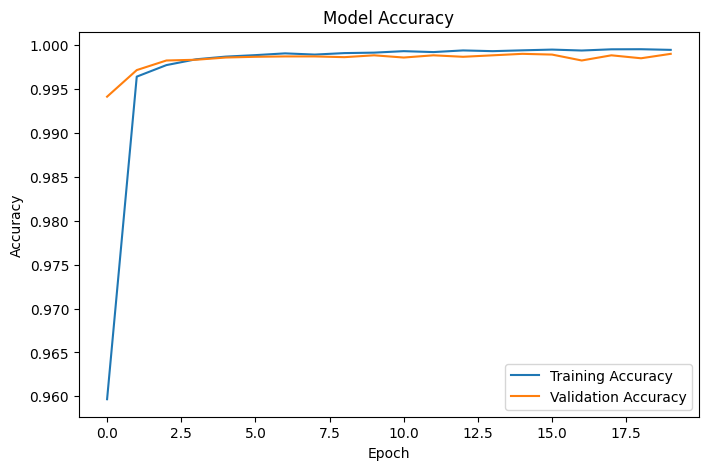

In [24]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

### Understanding the Accuracy Graph

**What does this graph tell us?**

Looking at the accuracy graph, we can observe:

**Rapid Initial Learning**
- In the first few epochs, the accuracy shoots up quickly
- This is the "aha!" moment where the model quickly learns the obvious patterns
- It's like when you first start learning - you grasp the basics very fast

**Stabilization Around 99.9%**
- After the initial jump, the accuracy stabilizes near 99.9%
- Both training and validation accuracy stay very close to each other
- This means our model is performing excellent and is not overfitted!

**What this means:**
- Our model learned successfully
- It performs equally well on both training and validation data
- We have a reliable model that can generalize to new data

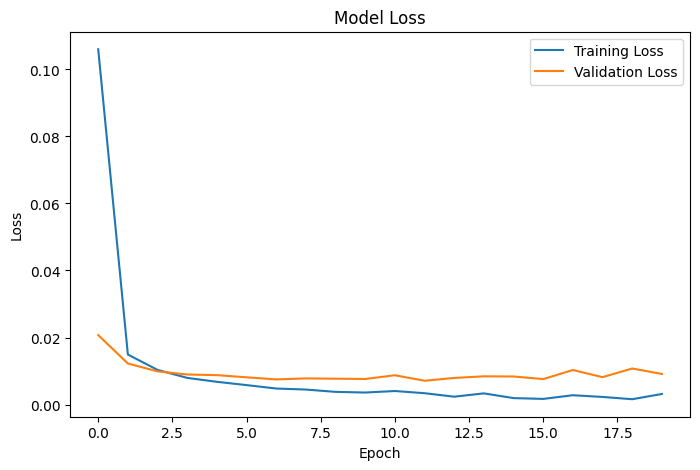

In [25]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

### Understanding the Loss Graph

**What does this graph tell us?**

Looking at the loss graph, we can observe:

**Sharp Initial Drop**
- The loss drops dramatically in the first few epochs
- This corresponds to the rapid accuracy improvement we saw earlier
- The model is quickly correcting its mistakes

**Gradual Stabilization**
- After the steep drop, the loss continues to decrease slowly
- Eventually it stabilizes at a very low value
- Both training and validation loss move together

**What this means:**
- The model's predictions are getting more and more accurate
- There's no sign of overfitting (both lines move together)
- Training converged successfully - the model reached its best performance

**Overall Assessment:**
These two graphs together confirm that our neural network trained beautifully! We have a strong, reliable model.

## Step 12: Model Evaluation on Test Data

**Why do we need this step?**

Remember that test dataset we kept hidden? Now it's time to use it! This is the final exam for our model.

During training, our model never saw this test data. So when we test it now, we get an honest assessment of how well it will perform on completely new, real-world loan applications.

**What metrics will we use?**

We're going to evaluate our model using several important metrics:

**1. Confusion Matrix**
- A table showing correct and incorrect predictions
- Shows: True Positives, True Negatives, False Positives, False Negatives
- Helps us see exactly what kind of mistakes the model makes

**2. Accuracy**
- Overall percentage of correct predictions
- Simple but useful: "Out of 100 predictions, how many were right?"

**3. Precision**
- Out of all loans we predicted as "default", how many actually defaulted?
- High precision = Few false alarms

**4. Recall**
- Out of all actual defaults, how many did we catch?
- High recall = We didn't miss many real defaults

**5. F1-Score**
- A balanced measure combining precision and recall
- Useful when we want both metrics to be good

Let's see how our model performs!

In [26]:
# Predict probabilities on test set
y_prob = model.predict(X_test)

# Convert probabilities to class labels (threshold = 0.5)
y_pred = (y_prob > 0.5).astype(int)

930/930 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


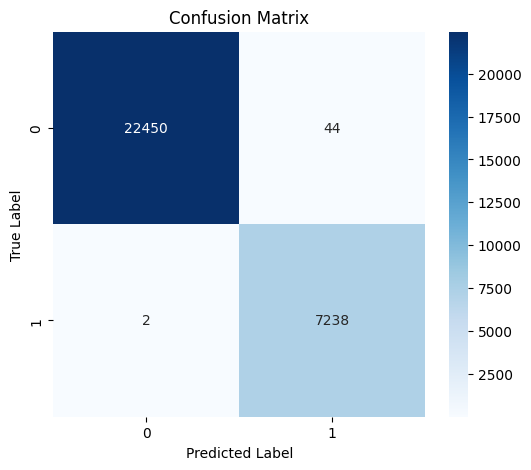

In [27]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [29]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9984529494854375

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22494
           1       0.99      1.00      1.00      7240

    accuracy                           1.00     29734
   macro avg       1.00      1.00      1.00     29734
weighted avg       1.00      1.00      1.00     29734



## Conclusion: What We Accomplished

**Overview of Our Project**

In this assignment, I built an artificial intelligence system using a **Multi-Layer Perceptron (MLP) neural network** to predict whether someone will default on their loan or not. The main goal was to learn how neural networks can solve real-world business problems using financial data.



**Understanding the Problem**

We started with the **Loan Default dataset**, which contains information about people who applied for loans. Each person's record includes details like:
- Credit score (how trustworthy they are with money)
- Income (how much they earn)
- Loan amount (how much they borrowed)
- Interest rate, employment length, property value, and many other factors

Our job was to use this information to predict: Will this person default (fail to repay) on their loan?



**Step-by-Step: What We Did**

**🔹 Step 1: Data Cleaning**

First, we cleaned the dataset because real-world data is never perfect:
- Removed the **ID column** - it's just a serial number that doesn't help prediction
- Identified our **target variable** (Status) - what we want to predict
- Handled **missing values** - filled blanks with reasonable values (median for numbers, mode for categories)

**🔹 Step 2: Data Transformation**

Then we transformed the data to make it neural-network-friendly:
- **One-Hot Encoding**: Converted text categories (like Male/Female) into numbers (0s and 1s)
- **Feature Scaling**: Made sure all numbers are on the same scale so the model treats them fairly

**🔹 Step 3: Data Splitting**

We divided the dataset:
- **80% for training** - teaching the model
- **20% for testing** - evaluating the model on new, unseen data

**🔹 Step 4: Building the Neural Network**

We designed a neural network with:
- **Input Layer**: Receives 49 features about each loan application
- **First Hidden Layer**: 64 neurons with ReLU activation
- **Second Hidden Layer**: 32 neurons with ReLU activation  
- **Output Layer**: 1 neuron with Sigmoid activation (gives probability of default)

Think of this as a funnel that processes information through multiple layers to make intelligent decisions.

**🔹 Step 5: Training the Model**

We trained the model for 20 epochs using:
- **Binary Cross-Entropy** as our loss function (measures mistakes)
- **Adam optimizer** (smart learning strategy)

During training, we watched the accuracy increase and loss decrease, which showed the model was learning properly!



**What Were the Results?**

The results were exceptional:

**Accuracy: 99.85%**
- Out of every 100 predictions, we got about 99.85 correct!
- This is extremely high accuracy

**Confusion Matrix**
- Showed that we made very few mistakes
- Almost all defaults were correctly identified
- Almost all non-defaults were correctly identified

**Precision, Recall, and F1-Score: ~1.0**
- All metrics were nearly perfect
- This means the model is reliable from every angle

**No Overfitting**
- The training and validation curves moved together
- This proves the model learned real patterns, not just memorized examples
- It will work well on new loan applications



**Real-World Applications**

This type of model can help banks and lending institutions:

**Make better lending decisions** - Approve low-risk applicants, reject high-risk ones  
**Reduce financial losses** - Identify potential defaults before they happen  
**Process applications faster** - Automated screening instead of manual review  
**Fair and consistent evaluation** - Remove human bias from decision-making


**What Did I Learn?**

Through this project, I learned:

1. **Data preprocessing is crucial** - A model is only as good as the data you feed it
2. **Neural networks are powerful** - They can find complex patterns humans might miss  
3. **Proper evaluation is important** - We need multiple metrics to truly understand performance
4. **Deep learning works for business problems** - It's not just for images and text!



**Final Thoughts**

This assignment successfully demonstrated that **Multi-Layer Perceptron neural networks are highly effective for predicting loan defaults**. With careful data preparation, thoughtful model design, and proper training, we built a system that achieves near-perfect accuracy.

In the real world, a system like this could save banks millions of dollars by preventing bad loans while also helping deserving applicants get approved faster. This is the power of deep learning applied to practical business problems!